In [3]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [4]:
torch.backends.mkldnn.enabled = True

In [5]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

100%|██████████| 170M/170M [00:18<00:00, 9.07MB/s] 


In [6]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 32 → 16
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 16 → 8
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    # nn.Conv2d(120, 120, 1),   # pointwise conv
    # nn.BatchNorm2d(120),
    # nn.PReLU(),

    nn.Conv2d(120, 120, 3, padding=1, groups=120),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    # nn.Conv2d(120, 120, 1),   # pointwise conv
    # nn.BatchNorm2d(120),
    # nn.PReLU(),
    nn.MaxPool2d(2),          # 8 → 4
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 4 → 2
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [7]:
model13_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model13_0)
describe(model13_0)

MACs: 5.93 MMac, Params: 26.55 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model13_0.pt
Starting
Epoch 1/60: Train loss = 1.3367, Train accuracy = 0.5402, Test loss = 1.2936, Test accuracy = 0.5606
Epoch 2/60: Train loss = 0.9466, Train accuracy = 0.6627, Test loss = 0.9063, Test accuracy = 0.6837
Epoch 3/60: Train loss = 0.8909, Train accuracy = 0.6824, Test loss = 0.8955, Test accuracy = 0.6835
Epoch 4/60: Train loss = 0.8219, Train accuracy = 0.7119, Test loss = 0.8369, Test accuracy = 0.7148
Epoch 5/60: Train loss = 0.7737, Train accuracy = 0.7336, Test loss = 0.7793, Test accuracy = 0.7393
Epoch 6/60: Train loss = 0.6871, Train accuracy = 0.7599, Test loss = 0.7052, Test accuracy = 0.7580
Epoch 7/60: Train loss = 0.7723, Train accuracy = 0.7349, Test loss = 0.7702, Test accuracy = 0.7396
Epoch 8/60: Train loss = 0.6155, Train accuracy = 0.7855, Test loss = 0.6343, Test accuracy = 0.7860
Epoch 9/60: Train loss = 0.6415, Train accuracy = 0.7732, Test loss = 0.6829, Test accuracy = 0.7646
Epoch 10/60: Train loss = 0.604

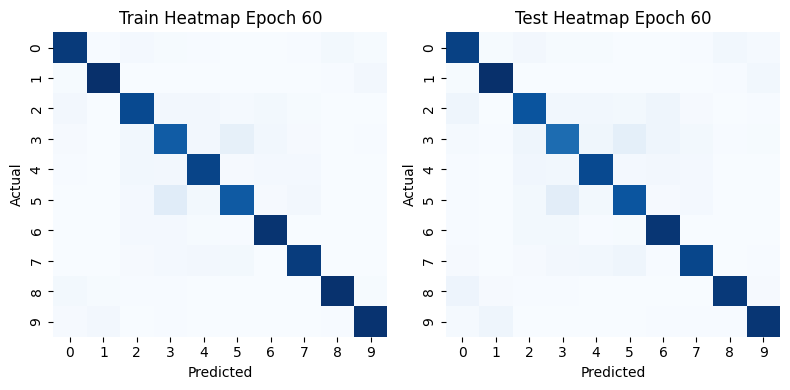

<Figure size 1200x600 with 0 Axes>

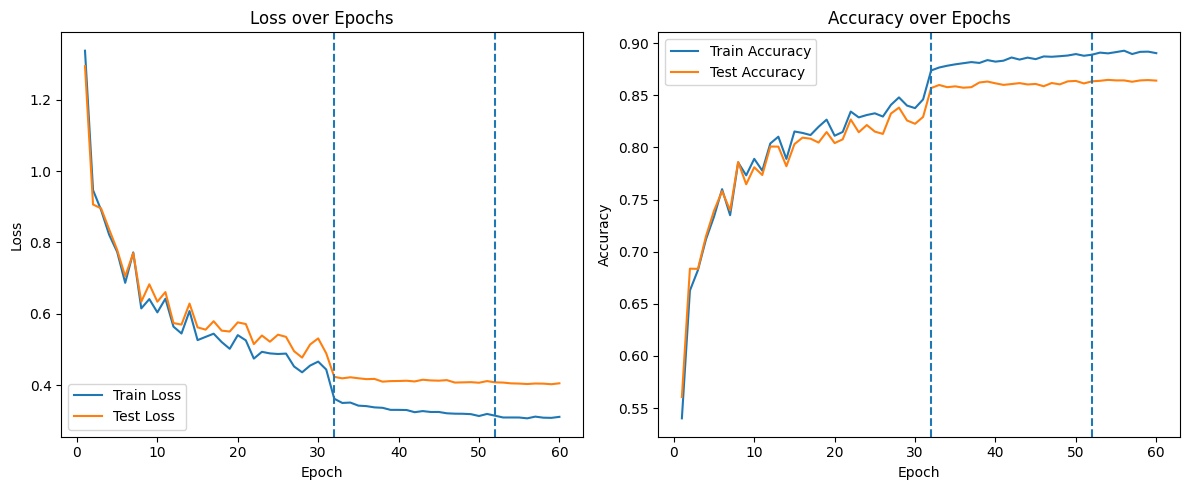

In [8]:
trainf32(model13_0,"model_weights/model13_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [9]:
model13_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model13_1)
describe(model13_1)

MACs: 5.93 MMac, Params: 26.55 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Starting
Epoch 1/60: Train loss = 1.0303, Train accuracy = 0.6366, Test loss = 0.9693, Test accuracy = 0.6566
Epoch 2/60: Train loss = 0.8544, Train accuracy = 0.6972, Test loss = 0.8184, Test accuracy = 0.7129
Epoch 3/60: Train loss = 0.8675, Train accuracy = 0.6974, Test loss = 0.8624, Test accuracy = 0.7071
Epoch 4/60: Train loss = 0.7467, Train accuracy = 0.7434, Test loss = 0.7508, Test accuracy = 0.7402
Epoch 5/60: Train loss = 0.6762, Train accuracy = 0.7625, Test loss = 0.6837, Test accuracy = 0.7640
Epoch 6/60: Train loss = 0.6214, Train accuracy = 0.7819, Test loss = 0.6254, Test accuracy = 0.7821
Epoch 7/60: Train loss = 0.7126, Train accuracy = 0.7567, Test loss = 0.7204, Test accuracy = 0.7587
Epoch 8/60: Train loss = 0.5984, Train accuracy = 0.7932, Test loss = 0.6207, Test accuracy = 0.7910
Epoch 9/60: Train loss = 0.5674, Train accuracy = 0.8024, Test loss = 0.5961, Test accuracy = 0.7992
Epoch 10/60: Train loss = 0.5844, Train accuracy = 0.7976, Test loss = 0.6112, Tes

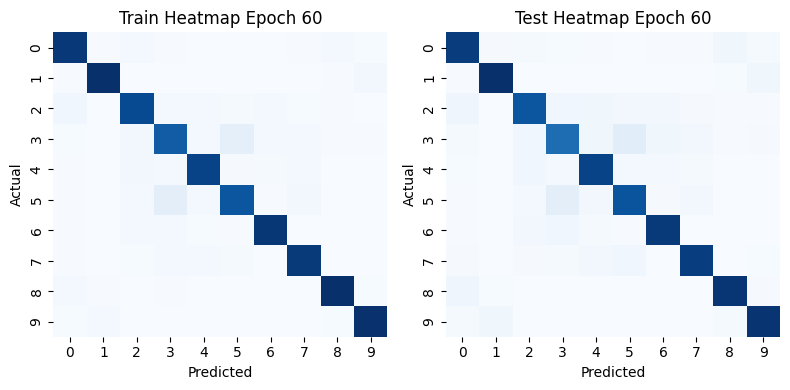

<Figure size 1200x600 with 0 Axes>

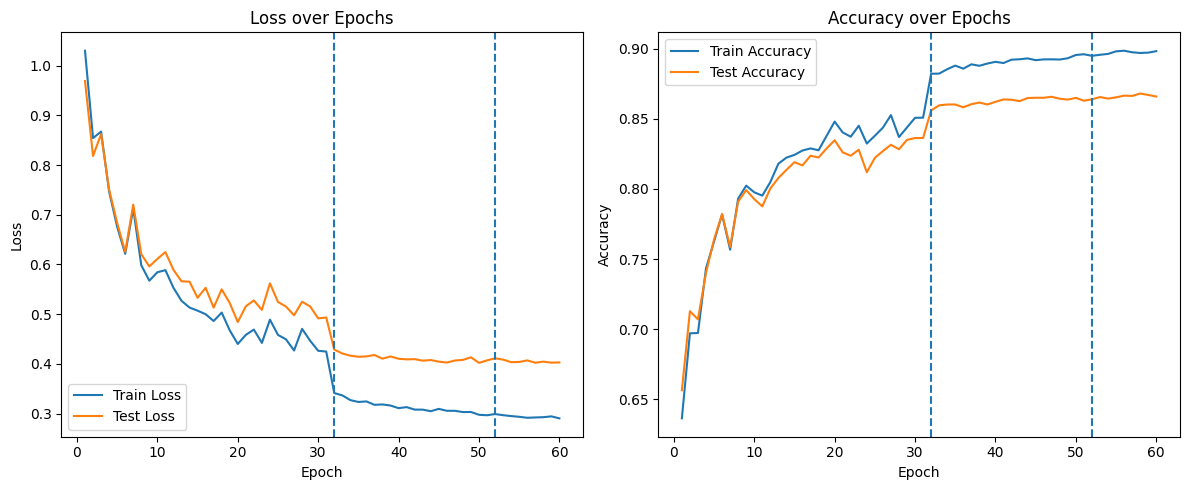

In [10]:
trainf32(model13_1,"model_weights/model13_1.pt",criterion,train_dataset,val_dataset, batch_size=64)